<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Face_Recognition_Modue_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Face Recognition using Python and Google Colab**

## **What is Face Recognition?**

![Image](https://images.openai.com/static-rsc-4/u5MjeCcDr79sFNW16tOp2WPZ45sFrjCPBxYRU1b642JpPEcECRwwyV-uTo8-4WwJnqi50JFH0BeM1oVCuwRm9McFcL2-XqEMFoqfDm22GWZsqGZH9tyBCR2ktcGW-gQbTgMWTRlWyDYj6kSO5p920JZ8oj6BIbhoIBgal4XRyPxo097kUQV3m3urU4J428mb?purpose=fullsize)


Face Recognition is an AI and Computer Vision technology that identifies or verifies a person using their face.

It works by:

1. Detecting a face in an image or video
2. Extracting unique facial features
3. Converting those features into numerical data (face embeddings)
4. Comparing them with stored faces
5. Predicting the identity

---

## Difference Between Face Detection and Face Recognition

| Technology       | Purpose                       |
| ---------------- | ----------------------------- |
| Face Detection   | Finds where faces are located |
| Face Recognition | Identifies whose face it is   |

Example:

* Detection → “There is a face in this image.”
* Recognition → “This is Lovnish.”

---

## How Face Recognition Works

![Image](https://images.openai.com/static-rsc-4/9jE5aOFdpBBlACyK56pv0QO4PGi7yVRRLeplllT2FGy7F_pq-pTQOc1Fq6TubJiWr9OfkHGV00ne_soC4rRVWKDoyLPKLKMN9g9Y7qQ59i-Hkir5PnUh__MQAVECVnRT1y-xLr_F_sklJsBtTW88vO7a8mdHmyI25dkIZsCukxUgrzuaFSc6-xsNreaMSF1G?purpose=fullsize)


### Step 1: Input Image

The system receives:

* image
* webcam frame
* CCTV feed
* video

---

### Step 2: Face Detection

AI locates the face coordinates.

Example:

```python
faces = face_recognition.face_locations(image)
```

---

### Step 3: Face Encoding

The face is converted into a numerical vector.

Usually:

* 128-dimensional embedding

Example:

```python
encoding = face_recognition.face_encodings(image)[0]
```

---

### Step 4: Comparison

The encoding is compared with stored encodings.

```python
matches = face_recognition.compare_faces(
    known_encodings,
    unknown_encoding
)
```

---

### Step 5: Prediction

Closest match becomes the predicted identity.

---

## Technologies Used

### Programming Languages

* Python
* C++
* JavaScript

### Libraries

* OpenCV
* dlib
* face_recognition
* DeepFace
* TensorFlow
* PyTorch

---

## Real World Applications

* Phone Unlock
* Attendance Systems
* Security Systems
* Smart Surveillance
* Airport Verification
* Banking Authentication
* Visitor Management

---

## Simple Face Recognition Flow

```text
Camera/Image
      ↓
Face Detection
      ↓
Face Encoding
      ↓
Compare with Database
      ↓
Identity Prediction
```

---

## Beginner-Friendly Python Example

```python
import face_recognition

# Load image
image = face_recognition.load_image_file("person.jpg")

# Detect faces
locations = face_recognition.face_locations(image)

# Generate encodings
encodings = face_recognition.face_encodings(image)

print("Faces Found:", len(locations))
```

---

## Popular Face Recognition Models

| Model        | Usage                            |
| ------------ | -------------------------------- |
| Haar Cascade | Basic detection                  |
| HOG          | Fast CPU detection               |
| CNN          | Accurate deep learning detection |
| FaceNet      | Face embeddings                  |
| ArcFace      | High accuracy recognition        |

---

## Advantages

* Fast authentication
* Contactless verification
* Automation
* Improved security

---

## Limitations

* Privacy concerns
* Lighting sensitivity
* Pose variations
* Bias in datasets
* Ethical concerns

---

## Beginner Learning Roadmap

1. Learn Python
2. Learn NumPy
3. Learn OpenCV
4. Learn Image Processing
5. Learn Face Detection
6. Learn Face Recognition
7. Build Projects
8. Learn Deep Learning

---

## Recommended Beginner Projects

* Smart Attendance System
* Face Unlock App
* AI Door Lock
* Visitor Counter
* Classroom Monitoring

---

## Important Ethical Considerations

Face Recognition should always be used responsibly:

* Take user consent
* Protect stored face data
* Avoid surveillance misuse
* Follow privacy laws

---

## Recommended Beginner Library

For beginners:

### `face_recognition`

Why:

* simple API
* very accurate
* beginner-friendly
* works well in Google Colab

Example install:

```python
!pip install face_recognition
```


## Step 1: Install Libraries

In [1]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=7b7b1ebbae3fa28d2d1db60e2478c8be5c6aa4af2549782be838179d81228566
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


## Step 2: Import Libraries

In [2]:
import cv2
import face_recognition
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from pathlib import Path
import os


## Step 3: What is Face Recognition?

### Face Detection
Finding where faces exist inside an image.

### Face Recognition
Identifying whose face it is.


## Step 4: Webcam Capture in Colab (using js)

In [3]:
def take_photo(filename='photo.jpg', quality=0.8):

    js = """
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    """

    display(Javascript(js))

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

## Step 5: Capture Your First Photo

This cell will be requesting browser permissions at 1st run

In [5]:
photo_path = take_photo('student.jpg')

print("Image saved:", photo_path)

<IPython.core.display.Javascript object>

Image saved: student.jpg


## Step 6: Display Image

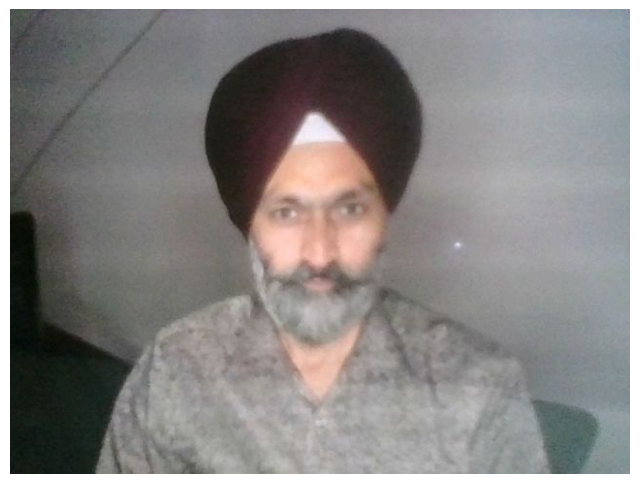

In [6]:
image = face_recognition.load_image_file(photo_path)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('off')
plt.show()

## Step 7: Detect Faces

In [7]:
face_locations = face_recognition.face_locations(image)

print("Faces Found:", len(face_locations))
print(face_locations)

Faces Found: 1
[(167, 390, 322, 236)]


## Step 8: Draw Face Rectangles

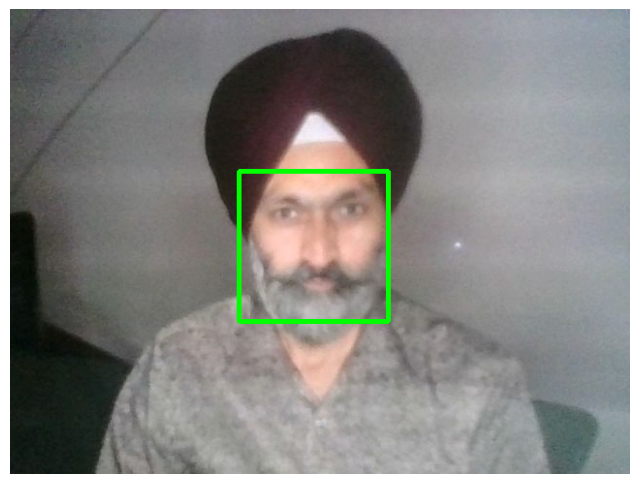

In [8]:
image_copy = image.copy()

for top, right, bottom, left in face_locations:

    cv2.rectangle(
        image_copy,
        (left, top),
        (right, bottom),
        (0,255,0),
        3
    )

plt.figure(figsize=(8,8))
plt.imshow(image_copy)
plt.axis('off')
plt.show()

## Step 9: Generate Face Encodings

In [9]:
encodings = face_recognition.face_encodings(image)

print("Total Encodings:", len(encodings))

if len(encodings) > 0:
    print("Encoding Vector Length:", len(encodings[0]))

Total Encodings: 1
Encoding Vector Length: 128


## Step 10: Create Dataset Folder

In [10]:
DATASET_DIR = Path("dataset")
DATASET_DIR.mkdir(exist_ok=True)

print("Dataset folder created")

Dataset folder created


## Step 11: Add Known Person

In [11]:
known_name = input("Enter Person Name: ")

person_dir = DATASET_DIR / known_name
person_dir.mkdir(exist_ok=True)

img_path = take_photo(f"{known_name}.jpg")

os.rename(img_path, person_dir / f"{known_name}.jpg")

print("Known face saved")

Enter Person Name: Sarwan Singh


<IPython.core.display.Javascript object>

Known face saved


## Step 12: Build Face Database

In [12]:
known_encodings = []
known_names = []

for person_name in os.listdir(DATASET_DIR):

    person_path = DATASET_DIR / person_name

    for image_name in os.listdir(person_path):

        image_path = person_path / image_name

        image = face_recognition.load_image_file(image_path)

        encodings = face_recognition.face_encodings(image)

        if len(encodings) > 0:

            known_encodings.append(encodings[0])
            known_names.append(person_name)

print("Database created successfully")
print("Total Faces:", len(known_names))

Database created successfully
Total Faces: 1


## Step 13: Test Face Recognition

<IPython.core.display.Javascript object>

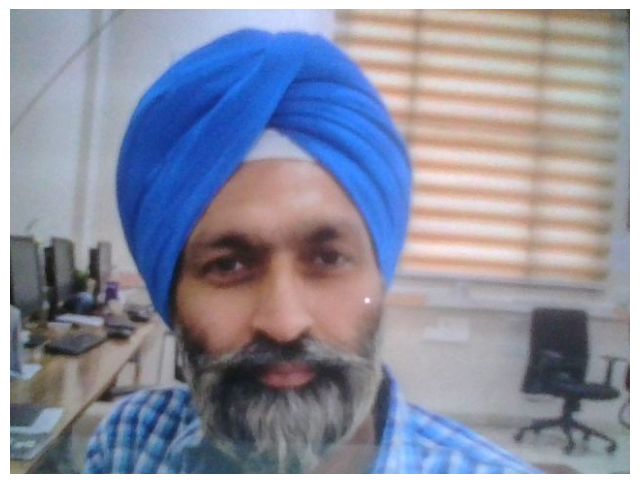

In [13]:
test_image_path = take_photo("test.jpg")

test_image = face_recognition.load_image_file(test_image_path)

plt.figure(figsize=(8,8))
plt.imshow(test_image)
plt.axis('off')
plt.show()

## Step 14: Recognize Faces

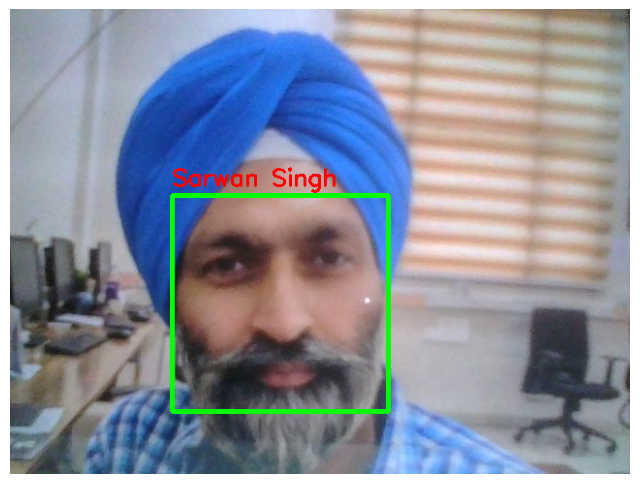

In [14]:
test_face_locations = face_recognition.face_locations(test_image)

test_face_encodings = face_recognition.face_encodings(
    test_image,
    test_face_locations
)

image_copy = test_image.copy()

for (top, right, bottom, left), face_encoding in zip(
    test_face_locations,
    test_face_encodings
):

    matches = face_recognition.compare_faces(
        known_encodings,
        face_encoding
    )

    name = "Unknown"

    face_distances = face_recognition.face_distance(
        known_encodings,
        face_encoding
    )

    if len(face_distances) > 0:

        best_match_index = np.argmin(face_distances)

        if matches[best_match_index]:
            name = known_names[best_match_index]

    cv2.rectangle(
        image_copy,
        (left, top),
        (right, bottom),
        (0,255,0),
        3
    )

    cv2.putText(
        image_copy,
        name,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,0,0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(image_copy)
plt.axis('off')
plt.show()


## Step 15: Common Errors

### No face found
- Improve lighting
- Keep face visible

### Webcam not opening
- Allow browser permissions
- Refresh runtime



# Exercises

1. Add 3 students
2. Detect multiple faces
3. Build attendance system
4. Count faces in classroom photo


# Congratulations

*You built your first AI Face Recognition system.*

<img src="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/raw_img/face_reco.png">